# To Be or Not to Be Shakespeare
## 01 — Data Collection


## 1. Imports and Setup

In [ ]:
!pip install striprtf

In [ ]:
import os
import re
import requests
import pandas as pd
from striprtf.striprtf import rtf_to_text

# Define explicit session paths inside a 'texts' base folder
DATA_PATH = "./texts"
PLAYS_DIR = os.path.join(DATA_PATH, "plays")
CONTEMPORARY_DIR = os.path.join(DATA_PATH, "contemporary")
DISPUTED_DIR = os.path.join(DATA_PATH, "disputed")

for folder in [DATA_PATH, PLAYS_DIR, CONTEMPORARY_DIR, DISPUTED_DIR]:
    os.makedirs(folder, exist_ok=True)

print(f"  Base: {DATA_PATH}\n  Plays: {PLAYS_DIR}\n  Contemporary: {CONTEMPORARY_DIR}\n  Disputed: {DISPUTED_DIR}")

  Base: ./texts
  Plays: ./texts/plays
  Contemporary: ./texts/contemporary
  Disputed: ./texts/disputed


## 2. Download Helper

In [ ]:
def get_gutenberg(book_id, filename, target_dir=DATA_PATH):
    """
    Download plain text from Project Gutenberg directly into the local target directory
    """
    urls = [
        f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt",
        f"https://www.gutenberg.org/files/{book_id}/{book_id}-0.txt",
        f"https://www.gutenberg.org/files/{book_id}/{book_id}.txt",
    ]

    for url in urls:
        r = requests.get(url)
        if r.status_code == 200 and len(r.text) > 1000:
            target_path = os.path.join(target_dir, filename)
            with open(target_path, "w", encoding="utf-8") as f:
                f.write(r.text)
            print(f"Saved {filename} to {target_path}")
            return

    print(f"Failed to get book {book_id}")

## 3. Shakespeare (Positive Class)

In [ ]:
get_gutenberg(100, 'shakespeare_complete1.txt', target_dir=DATA_PATH)

## 4. Contemporaries (Negative Class)

In [ ]:
# Marlowe — most important rival; candidate author for Henry VI
get_gutenberg(779,   'marlowe_faustus.txt', target_dir=CONTEMPORARY_DIR)
get_gutenberg(1094,  'marlowe_tamburlaine1.txt', target_dir=CONTEMPORARY_DIR)
get_gutenberg(1589,  'marlowe_tamburlaine2.txt', target_dir=CONTEMPORARY_DIR)
get_gutenberg(42724, "marlowe_jew_edward_massacre.txt", target_dir=DATA_PATH)

# Jonson — stylistically distinct anchor for the non-Shakespeare class
get_gutenberg(4081,  'jonson_alchemist.txt', target_dir=CONTEMPORARY_DIR)
get_gutenberg(4011,  'jonson_episcoene_silentwoman.txt', target_dir=DATA_PATH)
get_gutenberg(49461, 'jonson_bartholomew_fair.txt', target_dir=CONTEMPORARY_DIR)

# Fletcher — confirmed co-author of late Shakespeare plays; key for Double Falsehood
get_gutenberg(1124,  'fletcher_faithful_shepherdess.txt', target_dir=CONTEMPORARY_DIR)
get_gutenberg(12221, 'fletcher_beggars_bush.txt', target_dir=CONTEMPORARY_DIR)
get_gutenberg(50031, "fletcher_beaumont.txt", target_dir=DATA_PATH)

#Massinger
get_gutenberg(48440,  'massinger_plays.txt', target_dir=DATA_PATH)

# Nashe — candidate author for Henry VI; prose stylist
get_gutenberg(10467, 'nashe_summer_testament.txt', target_dir=CONTEMPORARY_DIR)

# Collection to get Kyd
get_gutenberg(45794, 'kyd_cornelia_soliman.txt', target_dir=DATA_PATH)

# Collection to get Green
get_gutenberg(55769, 'greene_plays.txt', target_dir=DATA_PATH)

## 5. Disputed Texts

In [ ]:
get_gutenberg(1500,  'henry_vi_part1.txt', target_dir=DISPUTED_DIR)
get_gutenberg(1501,  'henry_vi_part2.txt', target_dir=DISPUTED_DIR)
get_gutenberg(1502,  'henry_vi_part3.txt', target_dir=DISPUTED_DIR)
get_gutenberg(35330, 'spanish_tragedy.txt', target_dir=DISPUTED_DIR)

# Double Falsehood Download
url = 'https://www.greenblattrenaissance.com/assets/doublefalsehood.rtf'
r = requests.get(url)
if r.status_code == 200:
    rtf_path = os.path.join(DATA_PATH, 'double_falsehood.rtf')
    with open(rtf_path, 'wb') as f:
        f.write(r.content)
    print(f'Downloaded double_falsehood.rtf ({len(r.content):,} bytes)')

    # Read and convert RTF to plain text
    with open(rtf_path, 'r', encoding='latin-1') as f:
        rtf_content = f.read()
    text = rtf_to_text(rtf_content)

    # Strip biographical intro
    idx = text.find('Prologue')
    if idx != -1:
        text = text[idx:]

    target_file = os.path.join(DISPUTED_DIR, "double_falsehood.txt")
    with open(target_file, "w", encoding="utf-8") as f:
        f.write(text)
    print(f"Saved Double Falsehood to {target_file}")
else:
    print('Failed to download Double Falsehood')

## 6. Cleaning Shakespeare Complete

In [ ]:
def strip_gutenberg(text):
    """Remove Project Gutenberg header and footer."""
    text = text.lstrip('\ufeff')
    match = re.search(r'\*{3}\s*START OF[^\n]*\*{3}\s*\n', text)
    if match:
        text = text[match.end():]
    for marker in ['*** END OF', '***END OF', 'End of Project Gutenberg']:
        idx = text.find(marker)
        if idx != -1:
            text = text[:idx]
            break
    return text.strip()

def remove_play_safely(text, start_title, next_title_or_marker):
    """Removes a single specific block from the text safely."""
    start_idx = text.find(start_title)
    end_idx = text.find(next_title_or_marker)
    if start_idx == -1 or end_idx == -1:
        return text
    print(f"Removing text block between '{start_title}' and '{next_title_or_marker}'")
    return text[:start_idx] + text[end_idx:]

source_complete = os.path.join(DATA_PATH, 'shakespeare_complete1.txt')
with open(source_complete, 'r', encoding='utf-8') as file:
    raw_text = file.read()

clean_text = strip_gutenberg(raw_text)
clean_text = remove_play_safely(clean_text, "THE FIRST PART OF KING HENRY THE SIXTH", "THE LIFE OF KING HENRY THE FIFTH")
clean_text = remove_play_safely(clean_text, "THE SECOND PART OF KING HENRY THE SIXTH", "THE THIRD PART OF KING HENRY THE SIXTH")
clean_text = remove_play_safely(clean_text, "THE THIRD PART OF KING HENRY THE SIXTH", "THE TRAGEDY OF KING RICHARD THE THIRD")

output_clean = os.path.join(DATA_PATH, 'shakespeare_disputed_removed.txt')
with open(output_clean, 'w', encoding='utf-8') as file:
    file.write(clean_text)
print(f"Saved cleaned complete Shakespeare to {output_clean}")

Removing text block between 'THE SECOND PART OF KING HENRY THE SIXTH' and 'THE THIRD PART OF KING HENRY THE SIXTH'
Saved cleaned complete Shakespeare to ./texts/shakespeare_disputed_removed.txt


**IMPORTANT:**

 We have to note since the number of files is not large, striping parts that were not explicitly written by authors was done manually by selecting and deleting the text. This was a safer option because these parts are clearly visible to humans, so we did not lose any important data.

## Splitting anthology files into separate files

**NOTE:** From this point on, the notebook reads the manually cleaned files
(with non-authorial boilerplate removed by hand) from Google Drive, at
`My Drive/shakespeare_project/cleaned_manually`, instead of the local
auto-cleaned versions produced above.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Manually cleaned files (non-authorial text stripped by hand)
CLEANED_DIR = "/content/drive/My Drive/shakespeare_project/cleaned_manually"
CLEANED_CONTEMPORARY_DIR = os.path.join(CLEANED_DIR, "contemporary")
CLEANED_DISPUTED_DIR = os.path.join(CLEANED_DIR, "disputed")

print(f"  Cleaned base: {CLEANED_DIR}\n  Cleaned contemporary: {CLEANED_CONTEMPORARY_DIR}\n  Cleaned disputed: {CLEANED_DISPUTED_DIR}")

### Shakespeare complete collection

In [ ]:
SRC_FILE = os.path.join(CLEANED_DIR, "shakespeare_disputed_removed.txt")

with open(SRC_FILE, "r", encoding="utf-8") as f:
    lines = f.readlines()

canonical_titles = [
    "the sonnets", "all’s well that ends well", "the tragedy of antony and cleopatra",
    "as you like it", "the comedy of errors", "the tragedy of coriolanus", "cymbeline",
    "the tragedy of hamlet, prince of denmark", "the first part of king henry the fourth",
    "the second part of king henry the fourth", "the life of king henry the fifth",
    "king henry the eighth",
    "the life and death of king john", "the tragedy of julius caesar",
    "the tragedy of king lear", "love’s labour’s lost", "the tragedy of macbeth",
    "measure for measure", "the merchant of venice", "the merry wives of windsor",
    "a midsummer night’s dream", "much ado about nothing",
    "the tragedy of othello, the moor of venice", "pericles, prince of tyre",
    "the life and death of king richard the second", "king richard the third",
    "the tragedy of romeo and juliet", "the taming of the shrew", "the tempest",
    "the life of timon of athens", "the tragedy of titus andronicus",
    "troilus and cressida", "twelfth night; or, what you will",
    "the two gentlemen of verona", "the two noble kinsmen", "the winter’s tale",
    "a lover’s complaint", "the passionate pilgrim", "the rape of lucrece", "venus and adonis",
]

TOC_ZONE_LIMIT = 1000

matches = []
seen = set()
for i in range(TOC_ZONE_LIMIT, len(lines)):
    line = lines[i]
    stripped = line.strip().lower()
    if stripped in canonical_titles and stripped not in seen:
        matches.append((i, stripped))
        seen.add(stripped)
matches.sort()

print(f"Matched {len(matches)} / {len(canonical_titles)} expected titles")
missing = [t for t in canonical_titles if t not in seen]
if missing:
    print("MISSING (check these manually):", missing)

def slugify(title):
    s = title.replace("’", "'")
    s = re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")
    return s

manifest = []
for k, (start, title) in enumerate(matches):
    end = matches[k + 1][0] if k + 1 < len(matches) else len(lines)
    play_text = "".join(lines[start:end])
    fname = slugify(title) + ".txt"
    with open(os.path.join(PLAYS_DIR, fname), "w", encoding="utf-8") as out:
        out.write(play_text)
    manifest.append({"filename": fname, "title": title, "n_words": len(play_text.split())})

manifest_df = pd.DataFrame(manifest)
print(f"\nSplit into {len(manifest_df)} works, {manifest_df.n_words.sum():,} words total")

Matched 39 / 40 expected titles
MISSING (check these manually): ['the sonnets']

Split into 39 works, 869,576 words total


The only omitted work is The Sonnets, which was intentionally excluded because we compares plays only.

While The Tragedy of Titus Andronicus is included in the raw text splitting script, it was deliberately excluded from the final classification pipeline. Computational stylometrists heavily attribute Titus to a collaboration between Shakespeare and George Peele. We were unable to collect enough of Peele's solo work through The Gutenberg Project, which is required for confidently classifying the play as a multi-author text. Otherwise this play would have been in disputed folder.

In [ ]:
omitted_from_pipeline = ["the_tragedy_of_titus_andronicus.txt"]  # Dropped entirely due to Peele corpus constraints
poems = [
    "the_sonnets.txt", "venus_and_adonis.txt", "the_rape_of_lucrece.txt",
    "the_passionate_pilgrim.txt", "a_lover_s_complaint.txt",
]
collaborations = ["the_two_noble_kinsmen.txt"]

exclude_from_positive = set(omitted_from_pipeline + poems + collaborations)
all_split_files = set(manifest_df["filename"])
positive_files = sorted(all_split_files - exclude_from_positive)

print(f"Positive class (clean Shakespeare plays): {len(positive_files)} works")
print(f"Excluded from training: {len(exclude_from_positive)} works")

for f in sorted(exclude_from_positive):
    reason = (
        "omitted, structural collaboration with George Peele (insufficient baseline data)" if f in omitted_from_pipeline
        else "poem, different genre" if f in poems
        else "known collaboration (John Fletcher)"
    )
    print(f"  - {f}  ({reason})")

Positive class (clean Shakespeare plays): 33 works
Excluded from training: 7 works
  - a_lover_s_complaint.txt  (poem, different genre)
  - the_passionate_pilgrim.txt  (poem, different genre)
  - the_rape_of_lucrece.txt  (poem, different genre)
  - the_sonnets.txt  (poem, different genre)
  - the_tragedy_of_titus_andronicus.txt  (omitted, structural collaboration with George Peele (insufficient baseline data))
  - the_two_noble_kinsmen.txt  (known collaboration (John Fletcher))
  - venus_and_adonis.txt  (poem, different genre)


## Contemporary authors collections

In [ ]:
ANTHOLOGY_TITLES = {
    "fletcher_mons_chances_wildgoose.txt": [
        "THE TRAGEDY OF VALENTINIAN.",
        "THE CHANCES",
        "THE WILD-GOOSE CHASE",
    ],
    "greene_plays.txt": [
        "ORLANDO FURIOSO",
        "FRIAR BACON AND FRIAR BUNGAY",
        "JAMES THE FOURTH",
    ],
    "marlowe_jew_edward_massacre.txt": [
        "THE JEW OF MALTA",
        "EDWARD THE SECOND",
        "THE MASSACRE AT PARIS",
    ],
    "massinger_plays.txt": [
        "THE GREAT DUKE OF FLORENCE",
        "THE BONDMAN",
        "THE MAID OF HONOUR",
    ],
    "kyd_cornelia_soliman.txt": [
        "CORNELIA",
        "THE TRAGEDY OF SOLIMAN AND PERSEDA",
    ],
}
PLAY_START_SIGNAL_PAT = re.compile(r"\b(ACT\b|DRAMATIS\s+PERSON|Enter\b)", re.I)
def find_title_boundaries(text, titles, lookahead=3000):
    boundaries = []
    for title in titles:
        words = title.split()
        pat = re.compile(r"\s+".join(re.escape(w) for w in words), re.I)
        matches = list(pat.finditer(text))
        if not matches:
            print(f"  WARNING: title not found -- '{title}'")
            continue
        chosen = None
        for m in matches:
            window = text[m.end(): m.end() + lookahead]
            if PLAY_START_SIGNAL_PAT.search(window):
                chosen = m.start()
                break
        if chosen is None:
            chosen = matches[-1].start()
        boundaries.append((chosen, title))
    boundaries.sort()
    return boundaries

def slugify_title(title):
    return re.sub(r"[^a-z0-9]+", "_", title.lower()).strip("_")

def split_anthology(fname):
    source_path = os.path.join(CLEANED_CONTEMPORARY_DIR, fname)
    if not os.path.exists(source_path):
        print(f"  Skipped: {fname} is not present in {CLEANED_CONTEMPORARY_DIR}")
        return []

    with open(source_path, "r", encoding="utf-8-sig") as f:
        text = f.read()

    author = fname.split("_")[0]
    titles = ANTHOLOGY_TITLES[fname]
    boundaries = find_title_boundaries(text, titles)

    if len(boundaries) != len(titles):
        print(f"  Only matched {len(boundaries)}/{len(titles)} titles in {fname}")
        return []

    written = []
    for i, (start, title) in enumerate(boundaries):
        end = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(text)
        play_text = text[start:end]
        out_fname = f"{author}_{slugify_title(title)}.txt"

        with open(os.path.join(CLEANED_CONTEMPORARY_DIR, out_fname), "w", encoding="utf-8") as out:
            out.write(play_text)

        written.append(out_fname)
        print(f"  wrote {out_fname}  ({len(play_text.split()):,} words)")

    return written

all_new_files = []
for fname in ANTHOLOGY_TITLES:
    print(f"\n{fname}:")
    new_files = split_anthology(fname)
    if new_files:
        os.remove(os.path.join(CLEANED_CONTEMPORARY_DIR, fname))
        print(f"  removed original {fname}")
        all_new_files.extend(new_files)

print(f"\nTotal new files written to contemporary folder: {len(all_new_files)}")


fletcher_mons_chances_wildgoose.txt:
  wrote fletcher_the_tragedy_of_valentinian.txt  (48,634 words)
  wrote fletcher_the_chances.txt  (17,915 words)
  wrote fletcher_the_wild_goose_chase.txt  (22,666 words)
  removed original fletcher_mons_chances_wildgoose.txt

greene_plays.txt:
  Skipped: greene_plays.txt is not present in /content/drive/My Drive/shakespeare_project/cleaned_manually/contemporary

marlowe_jew_edward_massacre.txt:
  wrote marlowe_the_jew_of_malta.txt  (20,264 words)
  wrote marlowe_edward_the_second.txt  (22,731 words)
  wrote marlowe_the_massacre_at_paris.txt  (11,027 words)
  removed original marlowe_jew_edward_massacre.txt

massinger_plays.txt:
  wrote massinger_the_great_duke_of_florence.txt  (19,076 words)
  wrote massinger_the_bondman.txt  (18,137 words)
  wrote massinger_the_maid_of_honour.txt  (17,722 words)
  removed original massinger_plays.txt

kyd_cornelia_soliman.txt:
  wrote kyd_cornelia.txt  (15,187 words)
  wrote kyd_the_tragedy_of_soliman_and_perseda

In [ ]:
def list_txt_files(folder):
    if not os.path.isdir(folder):
        print(f"Folder not found: {folder}")
        return []
    return sorted(f for f in os.listdir(folder) if f.endswith(".txt"))

contemporary_filenames = list_txt_files(CLEANED_CONTEMPORARY_DIR)
disputed_filenames = list_txt_files(CLEANED_DISPUTED_DIR)

print(f"Found {len(contemporary_filenames)} files in {CLEANED_CONTEMPORARY_DIR}/")
print(f"Found {len(disputed_filenames)} files in {CLEANED_DISPUTED_DIR}/")

In [ ]:
GUTENBERG_START_PAT = re.compile(
    r"\*\*\*\s*START OF (THE|THIS) PROJECT GUTENBERG.*?External Link.*? \*\*\*|\*\*\*\s*START OF (THE|THIS) PROJECT GUTENBERG.*? \*\*\*",
    re.I | re.S
)
GUTENBERG_END_PAT = re.compile(r"\*\*\*\s*END OF (THE|THIS) PROJECT GUTENBERG.*", re.I | re.S)

def strip_gutenberg_boilerplate(text):
    """Safely strips Gutenberg boilerplate if present; otherwise leaves hand-trimmed text intact."""
    parts = GUTENBERG_START_PAT.split(text)
    text = parts[-1] if len(parts) > 1 else text
    parts = GUTENBERG_END_PAT.split(text)
    text = parts[0] if len(parts) > 1 else text
    return text

CAST_LIST_HEADING_PAT = re.compile(
    r"^\s*(DRAMATIS\s+PERSON(?:AE|Æ)|PERSONS\s+REPRESENTED|THE\s+PERSONS|CHARACTERS)\s*\.?\s*$",
    re.I | re.M
)
CAST_LIST_END_PAT = re.compile(r"\n\s*\n\s*(ACT\s+[IVX0-9]|SCENE\s+[IVX0-9]|Enter\s)", re.I)

def strip_cast_list(text):
    """
    Removes every DRAMATIS PERSONAE / cast-list block in the text.
    FIX: The 'break' prevents the loop from turning into a no-op
         infinite truncation spiral when structural end markers are absent.
    """
    while True:
        m = CAST_LIST_HEADING_PAT.search(text)
        if not m:
            return text
        tail = text[m.end():]
        end_m = CAST_LIST_END_PAT.search(tail)

        if end_m:
            end = m.end() + end_m.start()
            text = text[:m.start()] + text[end:]
        else:
            end = min(len(text), m.end() + 2000)
            text = text[:m.start()] + text[end:]
            break

    return text

def load_file(path):
    with open(path, "r", encoding="utf-8-sig") as f:
        text = f.read()
    text = strip_gutenberg_boilerplate(text)
    text = strip_cast_list(text)
    return text

POEMS = {
    "the_sonnets.txt", "a_lover_s_complaint.txt", "the_passionate_pilgrim.txt",
    "the_rape_of_lucrece.txt", "venus_and_adonis.txt"
}
COLLABORATIONS = {"the_two_noble_kinsmen.txt"}
DISPUTED_SHAKESPEARE = {"the_tragedy_of_titus_andronicus.txt"}

rows = []

for fname in positive_files:
    path = os.path.join(PLAYS_DIR, fname)

    if fname in DISPUTED_SHAKESPEARE:
        text = load_file(path)
        rows.append({
            "filename": "titus_andronicus.txt", "author": "titus_andronicus", "label": None,
            "text": text, "n_words": len(text.split())
        })

    elif fname in POEMS or fname in COLLABORATIONS:
        continue

    else:
        text = load_file(path)
        rows.append({
            "filename": fname, "author": "shakespeare", "label": 1.0,
            "text": text, "n_words": len(text.split())
        })

for fname in contemporary_filenames:
    author = fname.split("_")[0]
    text = load_file(os.path.join(CLEANED_CONTEMPORARY_DIR, fname))
    rows.append({
        "filename": fname, "author": author, "label": 0.0,
        "text": text, "n_words": len(text.split())
    })

for fname in disputed_filenames:
    if fname == "titus_andronicus.txt":
        continue
    work_id = fname[:-4]
    text = load_file(os.path.join(CLEANED_DISPUTED_DIR, fname))
    rows.append({
        "filename": fname, "author": work_id, "label": None,
        "text": text, "n_words": len(text.split())
    })

df = pd.DataFrame(rows)
df.head()

,filename,author,label,text,n_words
0,a_midsummer_night_s_dream.txt,shakespeare,1.0,A MIDSUMMER NIGHT’S DREAM\n\n\n\n\nContents\n\...,17157
1,all_s_well_that_ends_well.txt,shakespeare,1.0,ALL’S WELL THAT ENDS WELL\n\n\n\nContents\n\nA...,24487
2,as_you_like_it.txt,shakespeare,1.0,AS YOU LIKE IT\n\n\n\n\nContents\n\n ACT I\n S...,22993
3,cymbeline.txt,shakespeare,1.0,CYMBELINE\n\n\n\n\nContents\n\nACT I\nScene I....,28854
4,king_henry_the_eighth.txt,shakespeare,1.0,KING HENRY THE EIGHTH\n\n\n\n\nContents\n\n AC...,25772


In [ ]:
summary = df.groupby(["label", "author"], dropna=False)["n_words"].sum().sort_values(ascending=False)
print(summary)

print()
totals = df.groupby("label", dropna=False)["n_words"].sum()
print("Positive (Shakespeare):", f"{totals.get(1, 0):,}", "words")
print("Negative (contemporaries):", f"{totals.get(0, 0):,}", "words")
disputed_total = totals[totals.index.isna()].sum()
print("Disputed (held out):", f"{disputed_total:,}", "words")

if totals.get(0, 0) > 0:
    ratio = totals.get(1, 0) / totals.get(0, 0)
    print(f"Class balance ratio: {ratio:.2f}x")

label  author          
1.0    shakespeare         786329
0.0    jonson              123689
       marlowe             108220
       fletcher             93438
       green                65962
       massinger            54603
       kyd                  33820
NaN    henry_vi_part2       24833
       henry_vi_part3       23971
       spanish_tragedy      21907
       henry_vi_part1       21271
0.0    nashe                16991
NaN    double_falsehood      2019
Name: n_words, dtype: int64

Positive (Shakespeare): 786,329 words
Negative (contemporaries): 496,723 words
Disputed (held out): 94,001 words
Class balance ratio: 1.58x


In [ ]:
df.to_pickle("preprocessed_corpus_final.pkl")
print("Saved preprocessed_corpus_final.pkl —", len(df), "rows")
print(df["author"].value_counts(dropna=False))

Saved preprocessed_corpus_final.pkl — 59 rows
author
shakespeare         33
marlowe              6
fletcher             4
jonson               4
massinger            3
kyd                  2
green                1
nashe                1
double_falsehood     1
henry_vi_part1       1
henry_vi_part2       1
henry_vi_part3       1
spanish_tragedy      1
Name: count, dtype: int64


# EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import Counter
import re

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
df_known = df[df['label'].notna()].copy()
df_disputed = df[df['label'].isna()].copy()

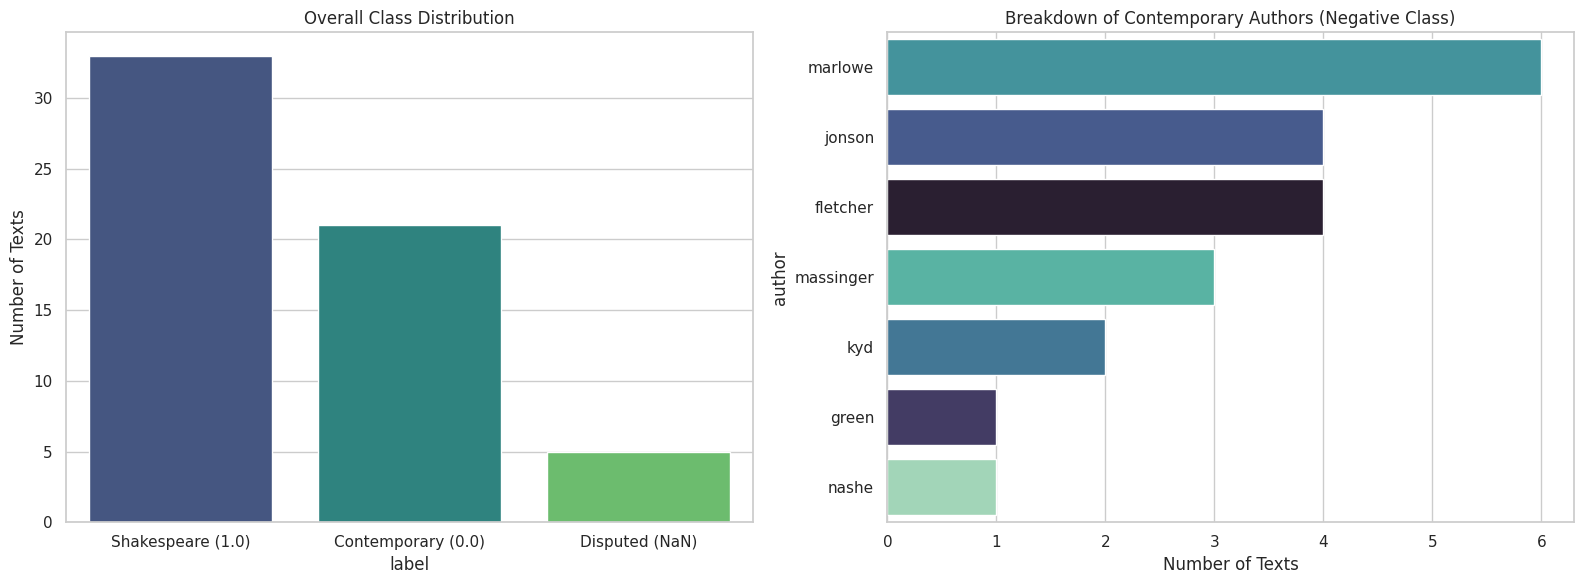

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Class Balance (Known vs Disputed)
labels_count = df['label'].value_counts(dropna=False)
labels_count.index = labels_count.index.map({1.0: 'Shakespeare (1.0)', 0.0: 'Contemporary (0.0)', np.nan: 'Disputed (NaN)'})
sns.barplot(x=labels_count.index, y=labels_count.values, hue=labels_count.index, ax=axes[0], palette="viridis", legend=False)
axes[0].set_title("Overall Class Distribution")
axes[0].set_ylabel("Number of Texts")

# 2. Contemporary Author Breakdown (Negative Class)
sns.countplot(data=df_known[df_known['label'] == 0.0], y='author', hue='author', ax=axes[1], order=df_known[df_known['label'] == 0.0]['author'].value_counts().index, palette="mako", legend=False)
axes[1].set_title("Breakdown of Contemporary Authors (Negative Class)")
axes[1].set_xlabel("Number of Texts")

plt.tight_layout()
plt.show()

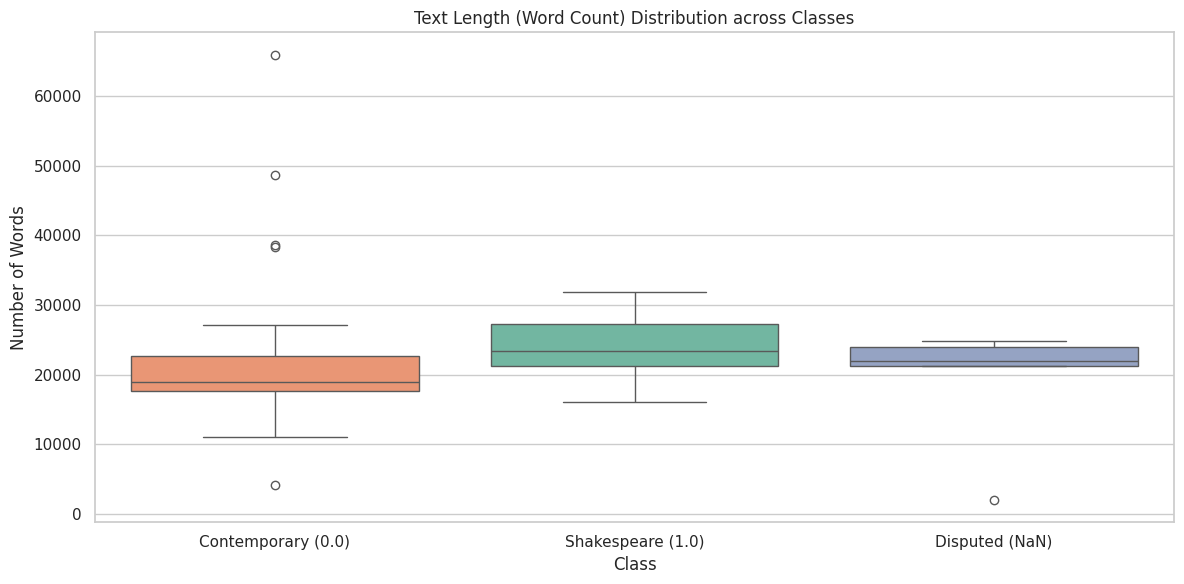

--- Word Count Statistics by Class ---
       count          mean           std      min      25%      50%      75%  \
label                                                                          
0.0     21.0  23653.476190  13861.047347   4223.0  17596.0  19023.0  22731.0   
1.0     33.0  23828.151515   4088.542055  16122.0  21265.0  23420.0  27308.0   
NaN      5.0  18800.200000   9493.386919   2019.0  21271.0  21907.0  23971.0   

           max  
label           
0.0    65962.0  
1.0    31865.0  
NaN    24833.0  


In [ ]:
df_plot = df.copy()
df_plot['class_name'] = df_plot['label'].map({
    1.0: 'Shakespeare (1.0)',
    0.0: 'Contemporary (0.0)'
}).fillna('Disputed (NaN)')

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_plot,
    x='class_name',
    y='n_words',
    hue='class_name',
    palette="Set2",
    legend=False,
    order=['Contemporary (0.0)', 'Shakespeare (1.0)', 'Disputed (NaN)']
)

plt.title("Text Length (Word Count) Distribution across Classes")
plt.xlabel("Class")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

print("--- Word Count Statistics by Class ---")
print(df.groupby('label', dropna=False)['n_words'].describe())

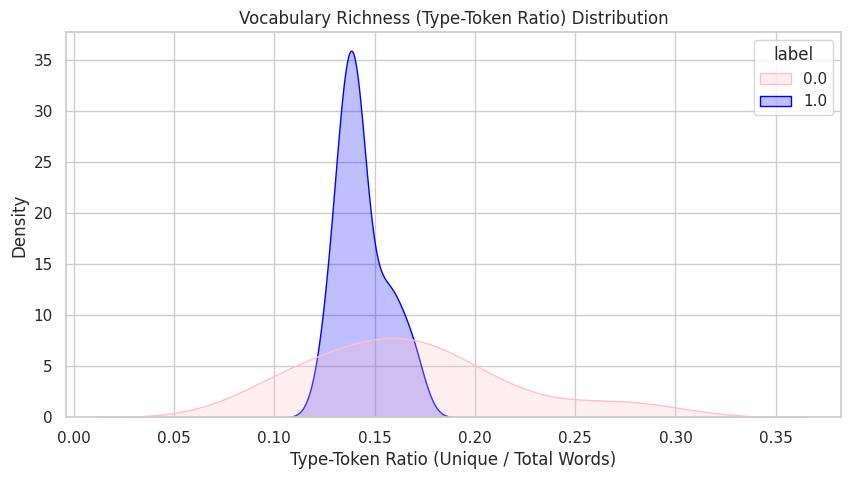

In [ ]:
def calculate_ttr(text):
    words = re.findall(r'\b\w+\b', text.lower())
    if not words: return 0
    return len(set(words)) / len(words)

df_known['ttr'] = df_known['text'].apply(calculate_ttr)
df_disputed['ttr'] = df_disputed['text'].apply(calculate_ttr)

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_known, x='ttr', hue='label', fill=True, common_norm=False, palette=["pink", "blue"])
plt.title("Vocabulary Richness (Type-Token Ratio) Distribution")
plt.xlabel("Type-Token Ratio (Unique / Total Words)")
plt.ylabel("Density")
plt.show()